# 04 · Reproducing Canciani 2022 — EKF38 with online calibration

The 38-state tightly-coupled filter, comparing **loosely-coupled** (static calibration) with **tightly-coupled** (online Tolles-Lawson calibration).

The F-16 flight data from the paper is non-public, so this uses public SGL (Cessna) data and emulates the F-16's large, stochastic body-field drift.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Flight, map, segment and kinematics

In [2]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import data, viz
from magnavlab.ins import build_kinematics, simulate_ins_pinson, inject_body_field_drift
from magnavlab.calibration import MapBasedModifiedTL
from magnavlab.filters import Canciani38EKF
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.geo import horizontal_error
from magnavlab.metrics import summary

nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
idx = segment_indices(nav, 50713.0, 54497.0)[::5]; dt = nav.dt * 5; n = idx.size
lat = np.radians(nav.get('lat')[idx]); lon = np.radians(nav.get('lon')[idx])
alt = nav.get('alt')[idx]; tt = nav.get('tt')[idx]
kinematics = build_kinematics(lat, lon, alt, dt,
                              np.radians(nav.get('roll')[idx]), np.radians(nav.get('pitch')[idx]))

## 2. Sensor signals: fluxgate, raw cabin scalar, core field, direction-cosine rates

In [3]:
flux = nav.flux(idx)
scalar = nav.get('mag_4_uc')[idx].astype(float)
core = nav.get('mag_1_c')[idx] - nav.get('igrf')[idx] - nav.get('diurnal')[idx]
cos_x, cos_y, cos_z = flux.x/scalar, flux.y/scalar, flux.z/scalar
cos_dot = (np.gradient(cos_x, dt), np.gradient(cos_y, dt), np.gradient(cos_z, dt))

## 3. Inject a body-frame stochastic drift (emulate the F-16 environment)
A drifting permanent field in the body frame, attitude-coupled through the direction cosines — a world-frame bias state cannot track it, but the online T-L states can.

In [4]:
scalar = inject_body_field_drift(scalar, flux, dt)   # sigma=0.6 nT/sqrt(s)

## 4. Simulate a navigation-grade drifting INS (Pinson integration, ~1 km drift)

In [5]:
ins, _ = simulate_ins_pinson(lat, lon, alt, kinematics, dt)
ins_drift = horizontal_error(ins['lat'], ins['lon'], lat, lon, lat)
print(f'INS drift: end={ins_drift[-1]:.0f} m, max={ins_drift.max():.0f} m')

INS drift: end=1083 m, max=1083 m


## 5. Batch modified map-based Tolles-Lawson (first 50%) to initialize the filter
Gives the initial T-L coefficient mean and covariance (eq. 23 of the paper).

In [6]:
half = n // 2
earth_field = mag_map.value(lat[:half], lon[:half]) + core[:half]
tl_batch = MapBasedModifiedTL().fit(nav.flux(idx[:half]), scalar[:half], dt, target=earth_field)
print(f'batch T-L residual = {tl_batch.resid_std:.1f} nT')

batch T-L residual = 35.8 nT


## 6. Assemble the estimation problem; run loosely- and tightly-coupled EKF38

In [7]:
problem = NavProblem(dt=dt, map=mag_map, lat=ins['lat'], lon=ins['lon'], alt=ins['alt'],
                     vN=ins['vN'], vE=ins['vE'], vD=ins['vD'], meas=scalar, core=core,
                     flux=flux, cos_dot=cos_dot, fn=kinematics['fn'], fe=kinematics['fe'],
                     fd=kinematics['fd'], Cnb=kinematics['Cnb'], tl0=tl_batch.coef, P_tl0=tl_batch.P_cov)
loose = Canciani38EKF(mode='loosely').run(problem)
tight = Canciani38EKF(mode='tightly').run(problem)
ins_result = NavResult(lat=ins['lat'], lon=ins['lon'])
for name, result in [('INS', ins_result), ('loosely', loose), ('tightly', tight)]:
    print(f"{name:9s} DRMS={summary(result, lat, lon)['drms']:8.1f} m")
ml = summary(loose, lat, lon)['drms']; mt = summary(tight, lat, lon)['drms']
print(f'improvement tightly vs loosely: {100*(1-mt/ml):.0f}%')

INS       DRMS=   493.5 m
loosely   DRMS=   102.0 m
tightly   DRMS=    55.1 m
improvement tightly vs loosely: 46%


## 7. MagNav position vs truth, overlaid on the anomaly map

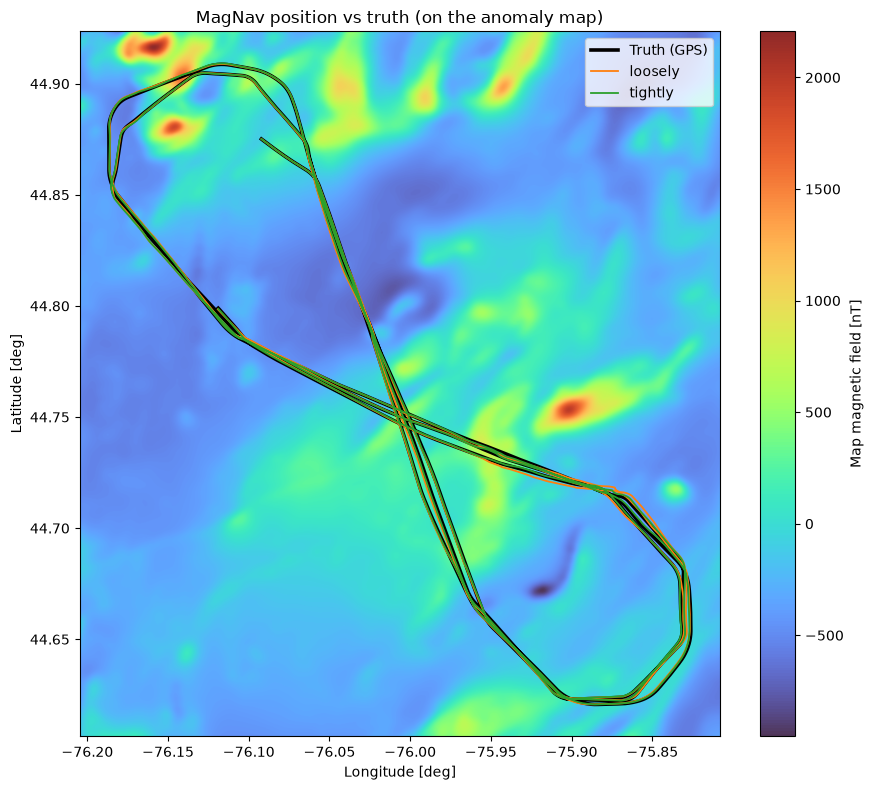

In [8]:
viz.plot_tracks_vs_truth(mag_map, lat, lon,
    {'loosely': (loose, 'tab:orange'), 'tightly': (tight, 'tab:green')});

## 8. Errors N/E (like Fig. 12–15) and the online T-L coefficient trace

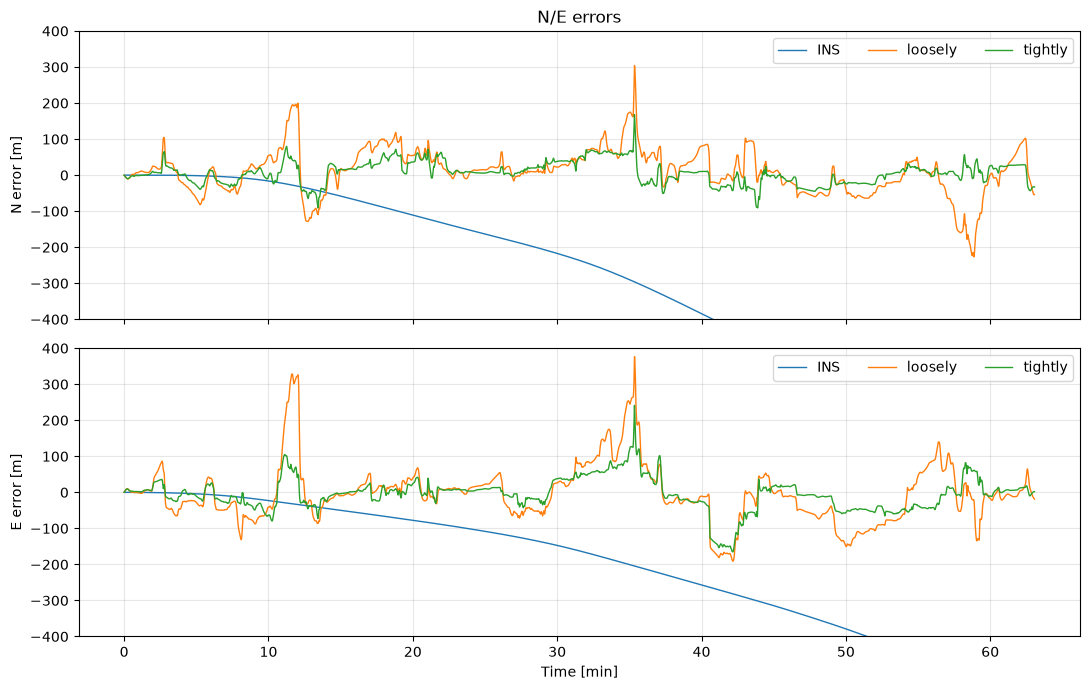

In [9]:
viz.plot_ne_errors(tt, lat, lon,
    {'INS': (ins_result,'tab:blue'), 'loosely': (loose,'tab:orange'), 'tightly': (tight,'tab:green')});

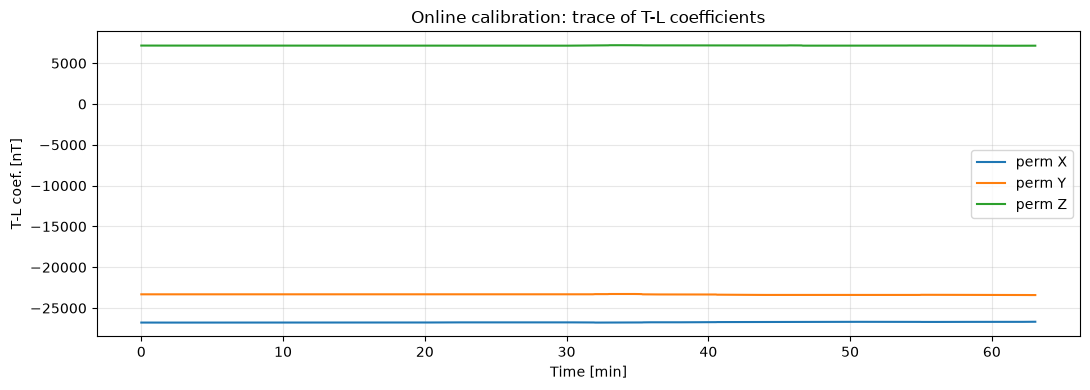

In [10]:
viz.plot_tl_online(tt, tight.extras['tl']);

On SGL data this gives loosely ~102 m, tightly ~55 m (~46% improvement), qualitatively matching Table I of the paper (F-16: 111 m → 59 m). To run on other flights, change the flight/window (see `data.NAV_WINDOWS`).